In [30]:
###################### Part 2 – Computer Vision Problem Formulation and CNN Prototype ###########################

# Imports

from pathlib import Path
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Task 1: Problem Identification

## Selected Problem Type: Image Classification

The given dataset represents an image classification problem. This dataset contains surface images of car panels, each belonging to exactly one of four defect categories. The goal is to assign the correct category label to each image.

## Why Image Classification?

This problem type is appropriate because:

Each image belongs to one predefined category/class.
The model predicts a single label for each image.
Images are organized into class folders.
The dataset does not contain bounding boxes or segmentation masks.

### Why Other Problem Types Do Not Apply
        
| Problem Type | Reason |
|---|---|
| Object Detection | Requires object location coordinates/bounding boxes |
| Semantic Segmentation | Requires pixel-level annotations |
| Instance Segmentation | Requires separate masks for each object |

Therefore, image classification is the correct computer vision formulation.

In [31]:
# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [32]:
# Create Output Directories

Path("results").mkdir(exist_ok=True)
Path("sample_predictions").mkdir(exist_ok=True)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Dataset Path
DATASET_PATH = Path("/content/drive/MyDrive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images")

In [35]:
###################### Task 2: Dataset Exploration #############################

# Load Class Names
classes = sorted([
    folder.name
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
])

print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['dent', 'normal', 'scratch', 'stain']
Total Classes: 4


In [36]:
# Count Images Per Class
image_count = {}

for cls in classes:
    class_path = DATASET_PATH / cls
    image_count[cls] = len(list(class_path.iterdir()))

print(image_count)

{'dent': 120, 'normal': 120, 'scratch': 120, 'stain': 120}


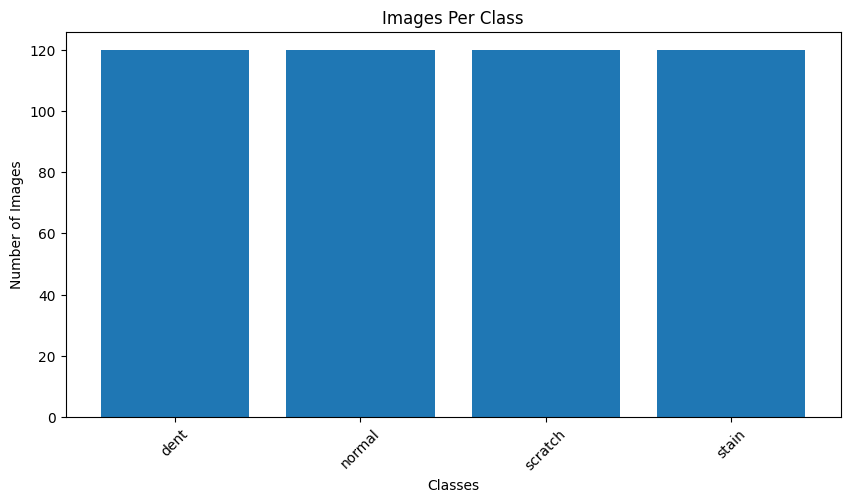

In [37]:
# Plot Class Distribution
plt.figure(figsize=(10,5))

plt.bar(image_count.keys(), image_count.values())

plt.xticks(rotation=45)
plt.title("Images Per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

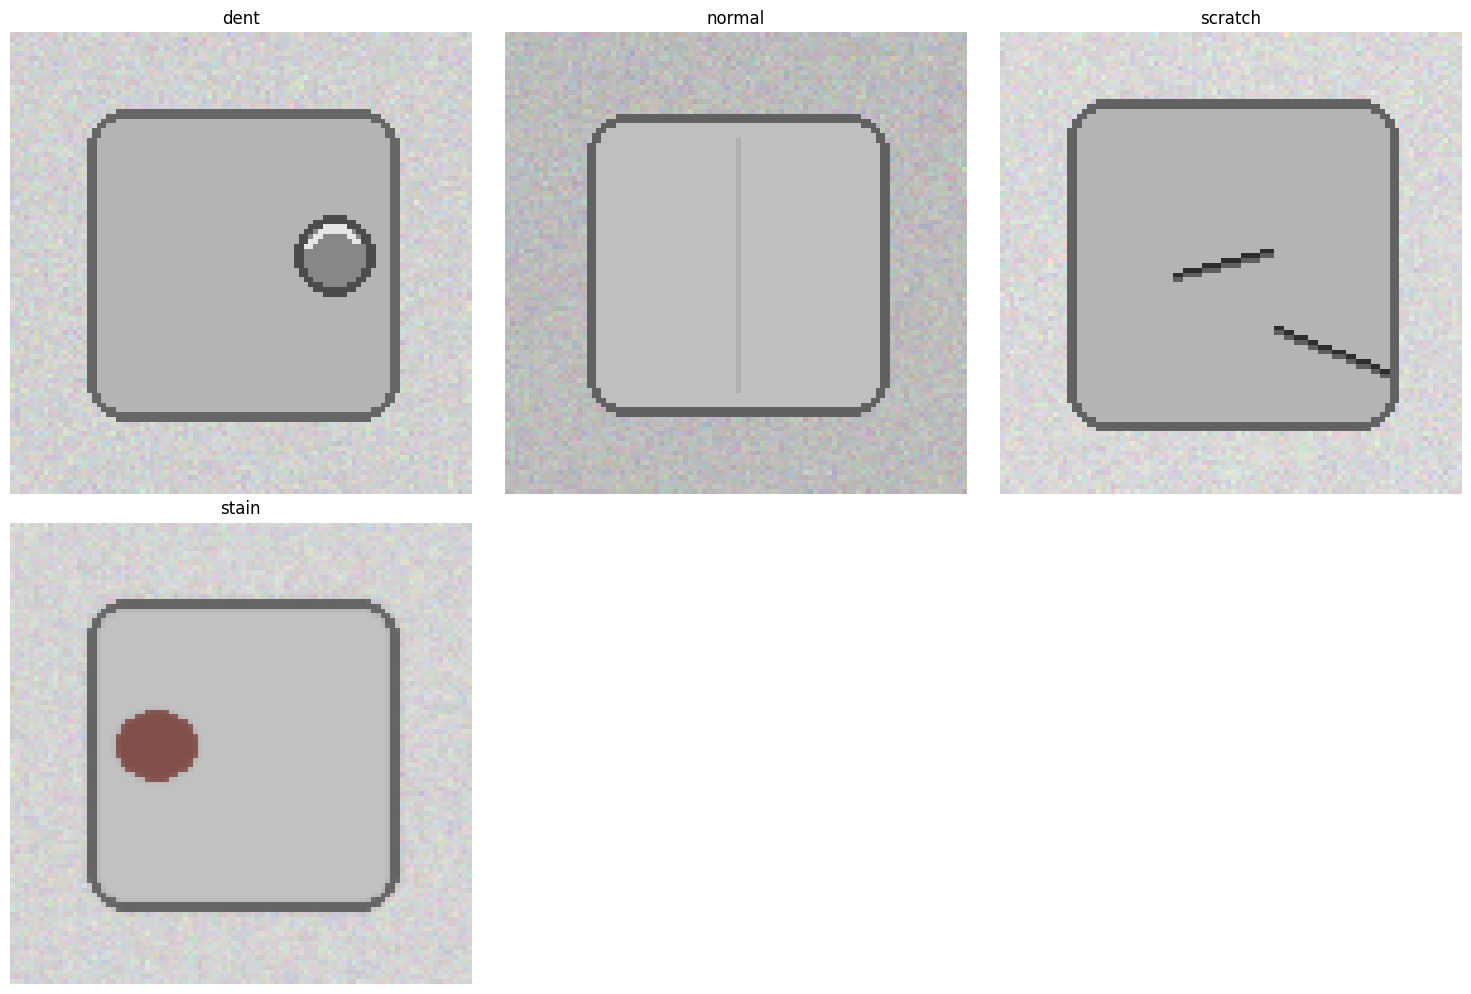

In [38]:
# Display Sample Images
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):

    class_path = DATASET_PATH / cls

    img_path = list(class_path.iterdir())[0]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, len(classes)//2 + 1, i+1)

    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
################### Task 3: Image Preprocessing ########################

# Image Preprocessing
IMAGE_SIZE = (128, 128)
INPUT_SHAPE = (128, 128, 3)

X = []
y = []

for label, cls in enumerate(classes):

    class_path = DATASET_PATH / cls

    for img_path in class_path.iterdir():

        img = cv2.imread(str(img_path))

        if img is not None:

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, IMAGE_SIZE)

            img = img / 255.0

            X.append(img)
            y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Dataset Shape:", X.shape)

Dataset Shape: (480, 128, 128, 3)


In [40]:
# Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))
print("Testing Samples:", len(X_test))

Training Samples: 336
Validation Samples: 72
Testing Samples: 72


In [41]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

In [42]:

########################## Task 4: CNN Model Creation #########################

# Build CNN Model

from tensorflow.keras.layers import Input

model = Sequential([

    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

In [43]:
# Compile Model
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Configure Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [46]:
##################### Task 5: Model Training and Evaluation #################

# Train Model
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.2381 - loss: 1.4937 - val_accuracy: 0.2778 - val_loss: 1.3861
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2470 - loss: 1.3891 - val_accuracy: 0.2917 - val_loss: 1.3863
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2351 - loss: 1.3869 - val_accuracy: 0.2500 - val_loss: 1.3865
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2500 - loss: 1.3888 - val_accuracy: 0.2500 - val_loss: 1.3862


In [47]:
# Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.2917 - loss: 1.3860
Test Accuracy: 0.2916666567325592
Test Loss: 1.385992169380188


In [48]:
# Save Final Model
model.save("cnn_image_classifier.keras")

In [49]:
#Save Training History
history_df = pd.DataFrame(history.history)

history_df.to_csv(
    'results/training_history.csv',
    index=False
)

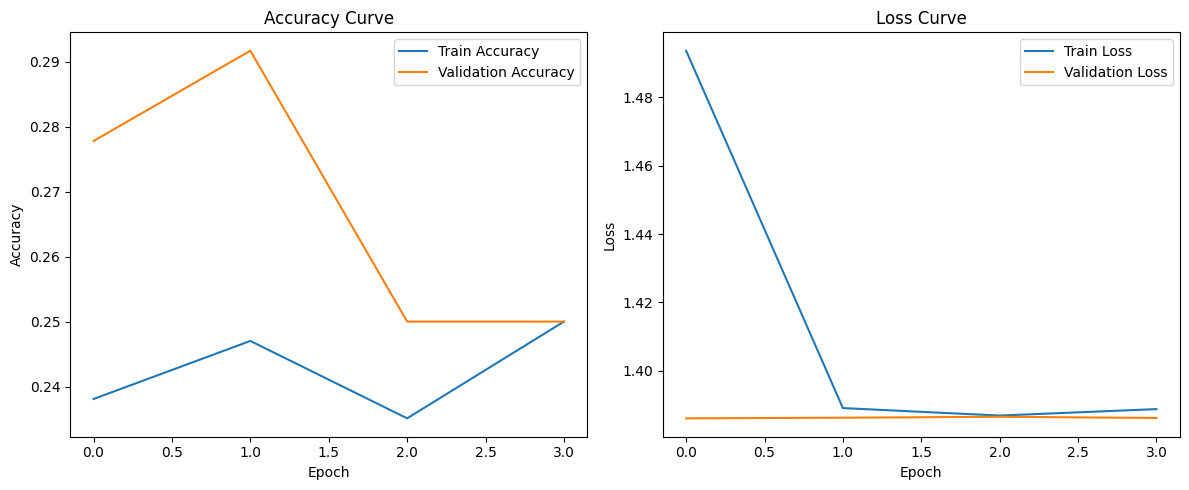

In [50]:

# Plot Accuracy and Loss Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

plt.savefig('results/accuracy_loss_curves.png')

plt.show()

In [51]:
# Predictions
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step


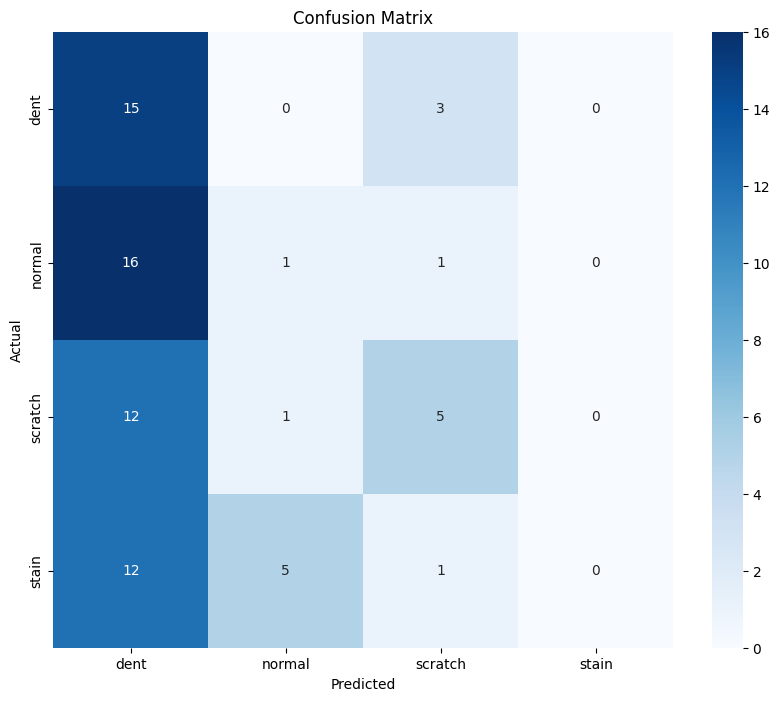

In [52]:
# Confusion Matrix
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes,
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig('results/confusion_matrix.png')

plt.show()

In [53]:
# Classification Report
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        dent       0.27      0.83      0.41        18
      normal       0.14      0.06      0.08        18
     scratch       0.50      0.28      0.36        18
       stain       0.00      0.00      0.00        18

    accuracy                           0.29        72
   macro avg       0.23      0.29      0.21        72
weighted avg       0.23      0.29      0.21        72



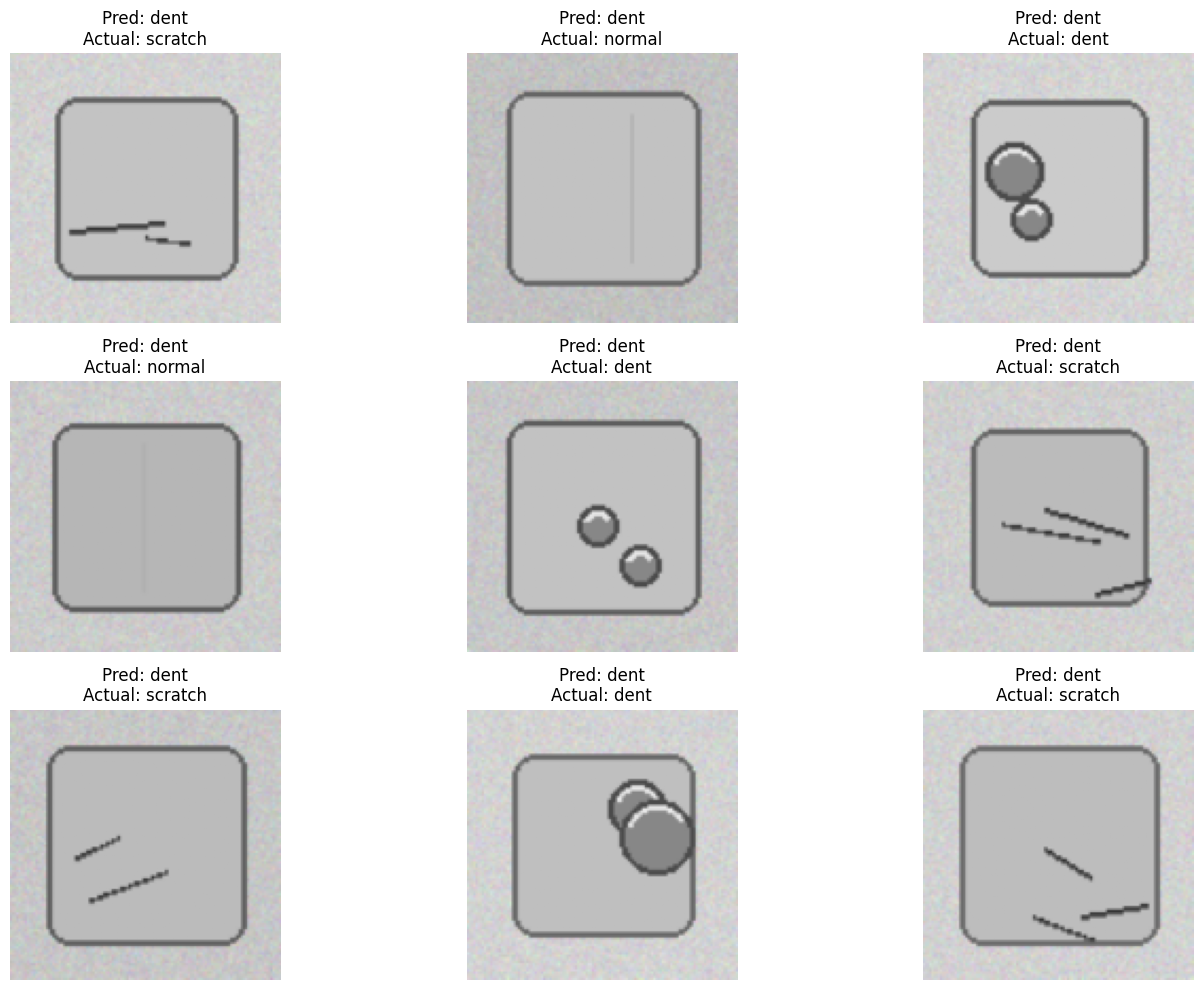

In [54]:
# Sample Predictions
plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    pred_label = classes[predicted_classes[i]]
    true_label = classes[y_test[i]]

    plt.title(
        f"Pred: {pred_label}\nActual: {true_label}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    'sample_predictions/prediction_outputs.png'
)

plt.show()